# 04 - Gözetimli Makine Öğrenmesi
## Uydu Telemetri Anomali Tespiti

Segment bazlı özellik matrisini kullanarak gözetimli anomali tespiti modellerini eğitmek.

### Modeller:
1. Random Forest
2. Support Vector Machine
3. XGBoost
4. MLP


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, sys
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

sys.path.insert(0, '..')
sys.path.insert(0, os.path.join('..', 'src'))
from src.models.supervised import SupervisedAnomalyDetector
from metrics import compute_metrics, metrics_table, BENCHMARK_METRICS

print('Kütüphaneler, Model Sınıfı ve metrik modülü yüklendi.')

I0000 00:00:1781342558.607239   40379 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781342558.633185   40379 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781342559.842329   40379 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


please install torch first
please install torch first
please install torch first
Kütüphaneler, Model Sınıfı ve metrik modülü yüklendi.


---
## Bölüm 1: Veri Hazırlama


In [2]:
# NB02 (ön işleme) çıktılarını yükle — resmi split, RobustScaler ölçekleme ve SMOTE
# orada (leakage-free) yapıldı; burada TEKRAR EDİLMEZ. Tek ön işleme kaynağı: NB02.
PROC = '../data/processed'
_Xtr = pd.read_parquet(f'{PROC}/X_train.parquet')   # RobustScaler + SMOTE'lu T eğitim
feature_cols = list(_Xtr.columns)
X_train_s = _Xtr.values
X_val_s  = pd.read_parquet(f'{PROC}/X_val.parquet').values    # RobustScaler + SMOTE'lu T validation
X_test_s = pd.read_parquet(f'{PROC}/X_test.parquet').values   # RobustScaler'lı resmi Ψ test
y_train_sm = pd.read_parquet(f'{PROC}/y_train.parquet')['anomaly']
y_val      = pd.read_parquet(f'{PROC}/y_val.parquet')['anomaly']
y_test     = pd.read_parquet(f'{PROC}/y_test.parquet')['anomaly']

print(f"NB02'den yüklendi — Train (SMOTE'lu T): {X_train_s.shape}, Val: {X_val_s.shape}, "
      f"Test Ψ: {X_test_s.shape}  ({len(feature_cols)} özellik, RobustScaler)")

NB02'den yüklendi — Train (SMOTE'lu T): (2164, 18), Val: (382, 18), Test Ψ: (529, 18)  (18 özellik, RobustScaler)


---
## Bölüm 2: Random Forest ve XGBoost


In [3]:
detector = SupervisedAnomalyDetector(random_state=42)
rf_model = detector.train_random_forest(X_train_s, y_train_sm, tune=False)
xgb_model = detector.train_xgboost(X_train_s, y_train_sm, X_val_s, y_val)


Random Forest eğitiliyor...


XGBoost eğitiliyor...


---
## Bölüm 3: SVM


In [4]:
svm_model = detector.train_svm(X_train_s, y_train_sm, kernel='rbf')


SVM (rbf kernel) eğitiliyor...


---
## Bölüm 4: MLP


MLP eğitiliyor...


Epoch 1/80


W0000 00:00:1781342562.647837   40379 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


 1/68 ━━━━━━━━━━━━━━━━━━━━ 54s 819ms/step - accuracy: 0.3750 - loss: 0.9230

42/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6306 - loss: 0.6234   

...

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9293 - loss: 0.1658 - val_accuracy: 0.9398 - val_loss: 0.1180


Epoch 52/80


 1/68 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9688 - loss: 0.0882

52/68 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - accuracy: 0.9380 - loss: 0.1438

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9348 - loss: 0.1541 - val_accuracy: 0.9529 - val_loss: 0.1088


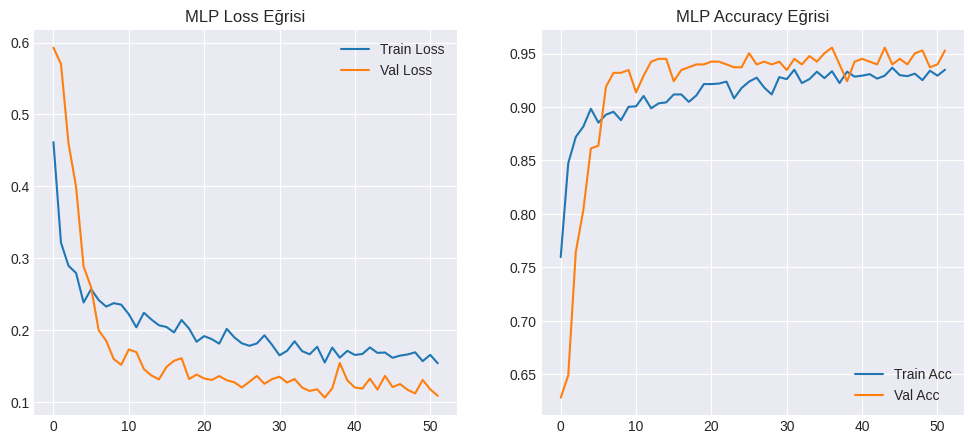

In [5]:
mlp_model, history = detector.train_mlp(X_train_s, y_train_sm.values, X_val_s, y_val.values, epochs=80, batch_size=32)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MLP Loss Eğrisi'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('MLP Accuracy Eğrisi'); plt.legend()
plt.show()


---
## Bölüm 5: Tüm Gözetimli Modeller

Yukarıda çekirdek 4 model (Random Forest, XGBoost, SVM, MLP) ayrıntılı işlendi.
Bu bölümde models_trained.txt'deki 23 gözetimli modelin tamamı, aynı SMOTE'lu ve
ölçeklenmiş eğitim verisiyle eğitilir; sonraki bölümde hepsi birlikte değerlendirilir.

In [6]:
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression as _LR

# SupervisedAnomalyDetector ile eğitilen klasik / topluluk modelleri (RF, XGBoost,
# SVM, MLP zaten Bölüm 2-4'te eğitildi):
detector.train_extra_trees(X_train_s, y_train_sm)
detector.train_xgbod(X_train_s, y_train_sm)
detector.train_gradient_boosting(X_train_s, y_train_sm)
detector.train_hist_gradient_boosting(X_train_s, y_train_sm)
detector.train_adaboost(X_train_s, y_train_sm)
detector.train_bagging(X_train_s, y_train_sm)
detector.train_decision_tree(X_train_s, y_train_sm)
detector.train_knn(X_train_s, y_train_sm)
detector.train_lsvc(X_train_s, y_train_sm)
detector.train_logistic_regression(X_train_s, y_train_sm)
detector.train_ridge(X_train_s, y_train_sm)
detector.train_sgd(X_train_s, y_train_sm)
detector.train_lda(X_train_s, y_train_sm)
detector.train_qda(X_train_s, y_train_sm)
detector.train_naive_bayes(X_train_s, y_train_sm)
detector.train_voting(X_train_s, y_train_sm)

# Detector dışı (train_all_models.py ile aynı yapılandırma): LightGBM, CatBoost, Stacking
detector.models['LightGBM'] = lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1).fit(X_train_s, y_train_sm)
detector.models['CatBoost'] = CatBoostClassifier(iterations=200, random_state=42, verbose=0).fit(X_train_s, y_train_sm)
detector.models['Stacking Ensemble'] = StackingClassifier(
    estimators=[(n, detector.models[n]) for n in ['RandomForest', 'LogisticRegression', 'KNN']],
    final_estimator=_LR(max_iter=500), cv=3, n_jobs=-1).fit(X_train_s, y_train_sm)

print(f"Eğitilen gözetimli model sayısı: {len(detector.models)}")
print(", ".join(detector.models.keys()))

Extra Trees eğitiliyor...


XGBOD eğitiliyor...


Gradient Boosting eğitiliyor...


HistGradientBoosting eğitiliyor...


AdaBoost eğitiliyor...


Bagging eğitiliyor...


Decision Tree eğitiliyor...
KNN (k=15) eğitiliyor...
Linear SVC eğitiliyor...
Logistic Regression eğitiliyor...
Ridge Classifier eğitiliyor...
SGD Classifier (log-loss) eğitiliyor...
LDA (Linear Discriminant Analysis) eğitiliyor...
QDA (Quadratic Discriminant Analysis) eğitiliyor...
Gaussian Naive Bayes eğitiliyor...
Voting Ensemble (soft) eğitiliyor...


Eğitilen gözetimli model sayısı: 23
RandomForest, XGBoost, SVM, MLP, ExtraTrees, XGBOD, GradientBoosting, HistGradientBoosting, AdaBoost, Bagging, DecisionTree, KNN, LSVC, LogisticRegression, Ridge, SGD, LDA, QDA, NaiveBayes, Voting Ensemble, LightGBM, CatBoost, Stacking Ensemble


---
## Bölüm 6: Değerlendirme (Tüm 23 Model)

In [7]:
def _scores(model, name):
    """Skor (AUC için) + ikili tahmin. Bazı modeller predict_proba'yı (n,) veya (n,1)
    döndürebilir ya da hiç olasılık vermez; bu yüzden boyut-güvenli ele alınır."""
    import numpy as _np
    if name == 'MLP':
        prob = _np.asarray(model.predict(X_test_s, verbose=0)).ravel()
        return prob, (prob >= 0.5).astype(int)
    pred = model.predict(X_test_s)                       # modelin kendi ikili kararı
    if hasattr(model, 'predict_proba'):
        pr = _np.asarray(model.predict_proba(X_test_s))
        prob = pr[:, 1] if (pr.ndim == 2 and pr.shape[1] > 1) else pr.ravel()
    elif hasattr(model, 'decision_function'):
        prob = _np.asarray(model.decision_function(X_test_s)).ravel()
    else:
        prob = _np.asarray(pred, dtype=float)
    return prob, pred

demo_metrics = {}
for name, model in detector.models.items():
    prob, pred = _scores(model, name)
    demo_metrics[name] = compute_metrics(y_test.values, pred, prob)

results_df = metrics_table(demo_metrics, sort_by='AUC_PR')
print(f"Tüm gözetimli modeller ({len(demo_metrics)}) — resmi Ψ (529 segment), AUC_PR sıralı:")
display(results_df[BENCHMARK_METRICS].style.background_gradient(cmap='Blues').format('{:.4f}'))

Tüm gözetimli modeller (23) — resmi Ψ (529 segment), AUC_PR sıralı:


,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
CatBoost,0.9565,0.9018,0.8938,0.8978,0.8702,0.9768,0.9503
Bagging,0.9584,0.9505,0.8496,0.8972,0.8734,0.9715,0.9450
XGBoost,0.9565,0.9167,0.8761,0.8959,0.8688,0.9742,0.9450
Stacking Ensemble,0.9603,0.9259,0.8850,0.9050,0.8803,0.9752,0.9443
LightGBM,0.9622,0.9346,0.8850,0.9091,0.8858,0.9692,0.9405
HistGradientBoosting,0.9527,0.8860,0.8938,0.8899,0.8598,0.9702,0.9391
RandomForest,0.9565,0.9245,0.8673,0.8950,0.8683,0.9655,0.9371
Voting Ensemble,0.9376,0.8390,0.8761,0.8571,0.8176,0.9697,0.9321
MLP,0.9074,0.7388,0.8761,0.8016,0.7464,0.9605,0.9206
GradientBoosting,0.9168,0.7851,0.8407,0.8120,0.7594,0.9613,0.9192


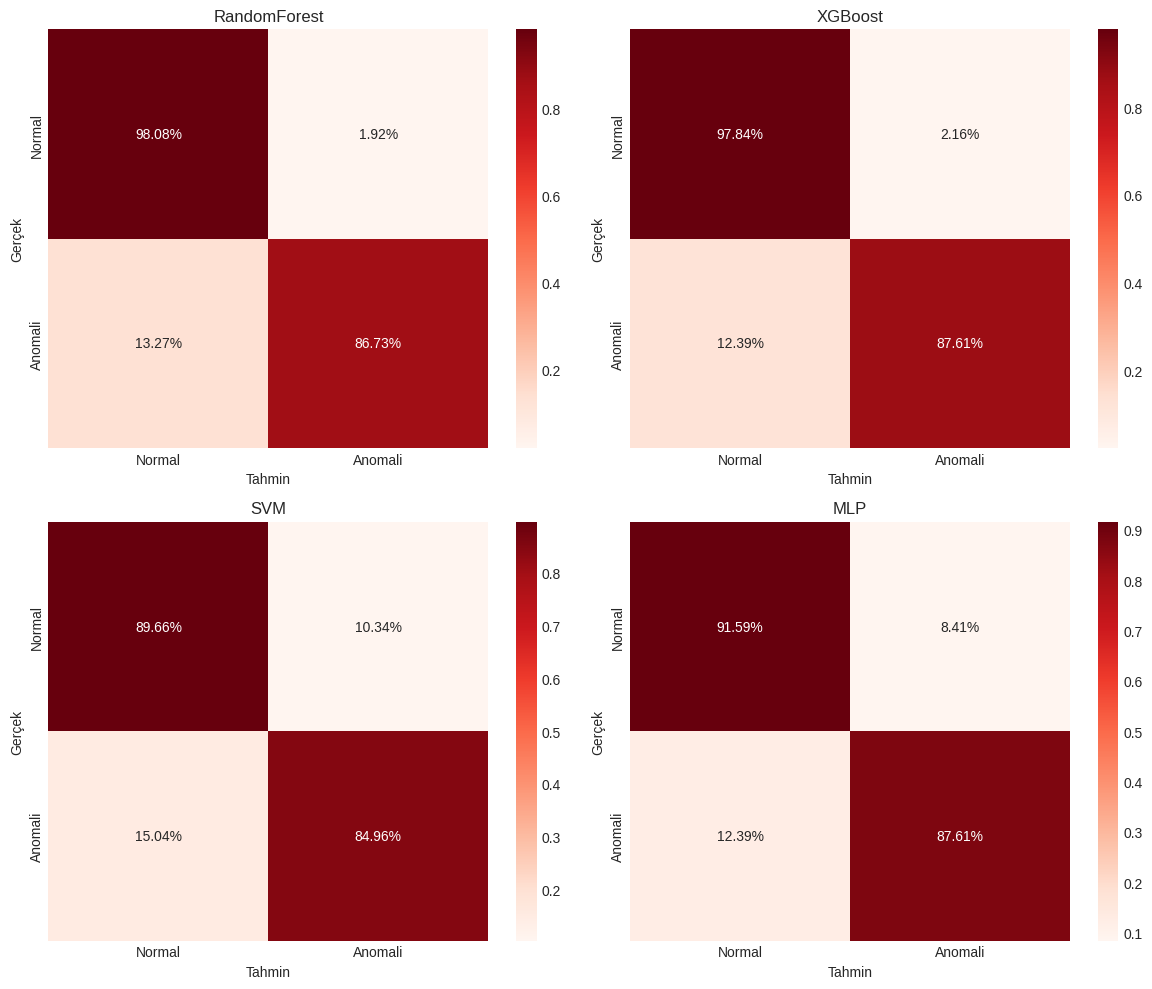

In [8]:
# Confusion matrisleri yalnız çekirdek 4 model için (okunabilirlik)
fig, axes = plt.subplots(2, 2, figsize=(12, 10)); axes = axes.flatten()
for i, name in enumerate(['RandomForest', 'XGBoost', 'SVM', 'MLP']):
    m = detector.models[name]
    yp = (m.predict(X_test_s, verbose=0) >= 0.5).astype(int).flatten() if name == 'MLP' else m.predict(X_test_s)
    cm = confusion_matrix(y_test, yp, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name); axes[i].set_xlabel('Tahmin'); axes[i].set_ylabel('Gerçek')
plt.tight_layout(); plt.show()

---
## Bölüm 7: ROC Eğrisi (Çekirdek Modeller)

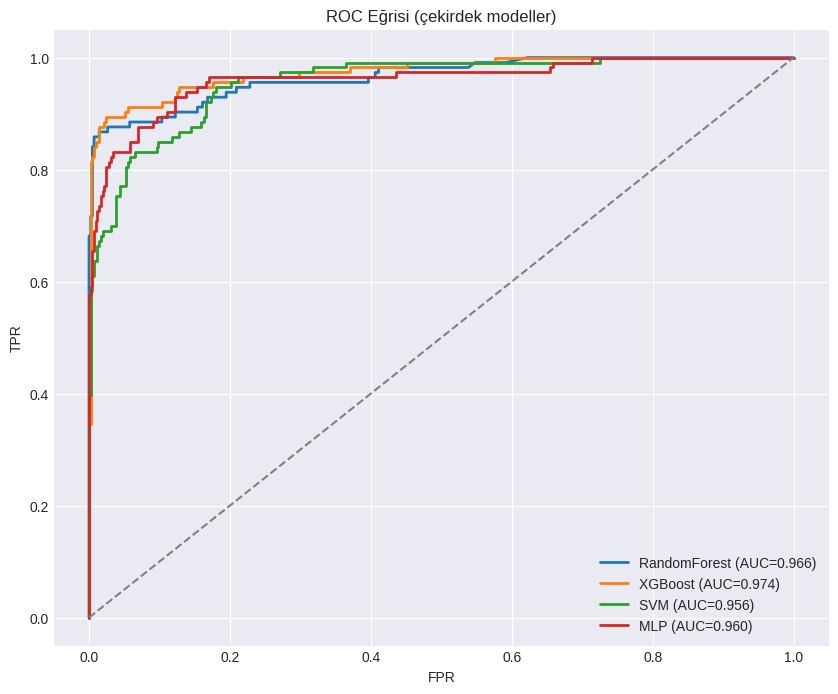

In [9]:
plt.figure(figsize=(10, 8))
for name in ['RandomForest', 'XGBoost', 'SVM', 'MLP']:
    model = detector.models[name]
    yp = model.predict(X_test_s, verbose=0).flatten() if name == 'MLP' else (model.predict_proba(X_test_s)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X_test_s))
    fpr, tpr, _ = roc_curve(y_test, yp); ra = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Eğrisi (çekirdek modeller)'); plt.legend(loc='lower right')
plt.show()

---
## Bölüm 8: Kaydetme

Yukarıda models_trained.txt'deki 23 gözetimli modelin tamamı gösterim amacıyla eğitilip
resmi Ψ üzerinde değerlendirildi. Kanonik (kaydedilen) artefaktlar ve nihai karşılaştırma
`train_all_models.py` ile üretilir, NB06'da raporlanır.

In [10]:
print("Bu notebook gösterim amaçlıdır; gözetimli model havuzunun tamamı train_all_models.py'de kanonik eğitilir, sonuçlar NB06'da.")

Bu notebook gösterim amaçlıdır; gözetimli model havuzunun tamamı train_all_models.py'de kanonik eğitilir, sonuçlar NB06'da.
